In [69]:
import numpy as np
import pandas as pd
from torch import nn
from torchvision import transforms 
# l library li bch naamlou biha redimension ll images
from torchvision import datasets 
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((128,128)),# redimension ll images 3la 128*128
    transforms.ToTensor(), # mli kenou les pixels de l'image entre 0 et 255 twali entre 0 et 1 
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]), #les valeurs ywaliw autour de 0 (-1,1)
    ]) 
test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ])  


In [71]:
#in_channels = 3 si image RGB 1 si image NB

In [72]:
trainData = datasets.ImageFolder(root="../data/train", transform=train_transform)
# smaller batch size gives more gradient updates per epoch
train_loader = DataLoader(trainData, batch_size=32, shuffle=True)
#data_loader t5ali l modele yaaml appel ll les images b 32 b 32 (batches) w shuffle true yeeni les images y3ytelhm en ordre
testData = datasets.ImageFolder(root="../data/test", transform=test_transform)
test_loader = DataLoader(testData, batch_size=32, shuffle=False)
#fyha tous les images mais m9asma en groupes de 32 chacune

In [73]:
len(trainData) #nombre total d'images fi trainData
len(train_loader) #nombre de groupes de 32 images (batches) fi train_loader

20

In [74]:
class ConvNeuralNet(nn.Module) : #nn.modules : classe fyh tous les modules li chnst7a9ouhm f cnn
    def __init__(self, num_classes = 2):
        super(ConvNeuralNet, self).__init__() #init : naamlou fyha definition ll les couches taa cnn
        self.convoLayer1 = nn.Conv2d(3,16,3,stride=1) 
        #Chaque kernel produit une image 2D appelée feature map (16 feature maps)
        self.relu = nn.ReLU() 
        self.pool = nn.MaxPool2d(2,2)
        self.convoLayer2 = nn.Conv2d(16,32,3, stride=1)
        self.relu = nn.ReLU() 
        self.pool = nn.MaxPool2d(2,2)
        self.convoLayer3 = nn.Conv2d(32,64,3, stride=1)
        self.relu = nn.ReLU() 
        self.pool = nn.MaxPool2d(2,2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64*14*14, 512)
        self.output = nn.Linear(512, num_classes) 
        #lvaleur l theny hwa nbr de classes de sortie
    def forward(self, x): #forward : bch napplikiw aa les images mteena les couches li f init
        out = self.convoLayer1(x)
        out = self.relu(out)
        out = self.pool(out)
        out = self.convoLayer2(out)
        out = self.relu(out)
        out = self.pool(out)
        out = self.convoLayer3(out)
        out = self.relu(out)
        out = self.pool(out)
        out = self.flatten(out)
        out = self.fc1(out)
        out = self.output(out)
        return out
    

torch.Size([32, 3, 128, 128])
torch.Size([32])


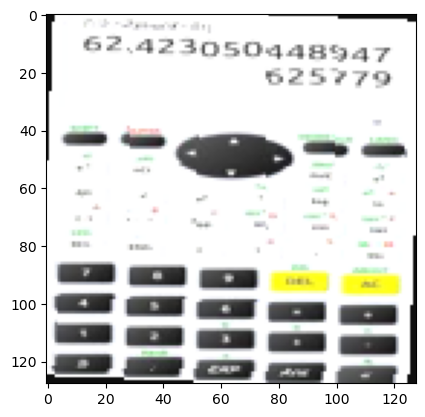

In [115]:
# itérer sur les batches
for images, labels in train_loader:
    print(images.shape)   # torch.Size([32, 3, 128, 128]) — 32 images
    print(labels.shape)   # torch.Size([32])
    
    # afficher la première image du batch
    img = images[1
    ]
    plt.imshow(img.permute(1, 2, 0) * 0.5 + 0.5)
    plt.show()
    
    break  # juste le premier batch

In [76]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [77]:
model = ConvNeuralNet(num_classes=2) 
model = model.to(device) 
loss_fct = nn.CrossEntropyLoss() #calcul de taux d'erreur entre valeurs réels et predictions du modèle
#optimoizer : bch naamlou update ll les poids mteena 3la 7asb taux d'erreur (loss function)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #lr : vitesse de l'apprentissage (learning rate) 0.001 : valeur classique

In [78]:
for j in range (200) : #9adeh men mara kol image bch ysirlha training (passage par tous les couches)
    for i, (images, labels) in enumerate(train_loader): #images heya x li f modéle
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images) 
        loss = loss_fct(outputs, labels)
        optimizer.zero_grad() #bch naamlou reset ll les gradients mteena
        loss.backward() #bch naamlou calcul ll les gradients mteena
        optimizer.step() #bch naamlou update ll les poids mteena 3
        print('Epoch [{}/{}], Loss: {:.4f}'.format(j+1, 20, loss.item()))

Epoch [1/20], Loss: 0.6939
Epoch [1/20], Loss: 4.0187
Epoch [1/20], Loss: 1.1866
Epoch [1/20], Loss: 2.3869
Epoch [1/20], Loss: 2.2247
Epoch [1/20], Loss: 1.6909
Epoch [1/20], Loss: 0.7044
Epoch [1/20], Loss: 0.6629
Epoch [1/20], Loss: 0.7245
Epoch [1/20], Loss: 0.7656
Epoch [1/20], Loss: 0.6515
Epoch [1/20], Loss: 0.6852
Epoch [1/20], Loss: 0.5828
Epoch [1/20], Loss: 0.6257
Epoch [1/20], Loss: 0.6253
Epoch [1/20], Loss: 0.5536
Epoch [1/20], Loss: 0.6120
Epoch [1/20], Loss: 0.9342
Epoch [1/20], Loss: 0.7141
Epoch [1/20], Loss: 0.3320
Epoch [2/20], Loss: 0.6486
Epoch [2/20], Loss: 0.6691
Epoch [2/20], Loss: 0.5852
Epoch [2/20], Loss: 0.6640
Epoch [2/20], Loss: 0.6310
Epoch [2/20], Loss: 0.6161
Epoch [2/20], Loss: 0.5927
Epoch [2/20], Loss: 0.5666
Epoch [2/20], Loss: 0.6738
Epoch [2/20], Loss: 0.6463
Epoch [2/20], Loss: 0.6503
Epoch [2/20], Loss: 0.6503
Epoch [2/20], Loss: 0.6052
Epoch [2/20], Loss: 0.5308
Epoch [2/20], Loss: 0.5224
Epoch [2/20], Loss: 0.6808
Epoch [2/20], Loss: 0.5797
E

Testing

In [80]:
with torch.no_grad(): #n7absou l training
    correct = 0
    total = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) #torch.max : bch naamlou calcul ll les predictions mteena , 1 maaneha chercher dans les colonnes
        total += labels.size(0) #total : nombre total d'images testées
        correct += (predicted == labels).sum().item() #correct : nombre d'images correctement classées
    print(total)
    print(correct)
    accuracy = 100 * correct / total
    print(f'Accuracy: {accuracy:.2f}%')

609
607
Accuracy: 99.67%


In [81]:
with torch.no_grad(): #n7absou l training
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) #torch.max : bch naamlou calcul ll les predictions mteena , 1 maaneha chercher dans les colonnes
        total += labels.size(0) #total : nombre total d'images testées
        correct += (predicted == labels).sum().item() #correct : nombre d'images correctement classées
    print(total)
    print(correct)
    accuracy = 100 * correct / total
    print(f'Accuracy: {accuracy:.2f}%')

193
176
Accuracy: 91.19%
